# Example 1: Symbolic Regressor

In [43]:
import sys
from pathlib import Path

# Add the parent folder (my_project) to Python's search path
sys.path.append(str(Path.cwd().parent))

from sklearn.utils.random import check_random_state
import numpy as np
from sklearn.metrics import r2_score
import math
from joblib import dump, load
from enum import StrEnum
from scipy.stats import spearmanr
from gplearn.genetic_ppm import SymbolicRegressor

In [44]:
def generate_benchmark_data(
    name, n_samples, rng, use_gaussian=False, scale_factor=1.0
):
    """Generates benchmark dataset with optional Gaussian distribution sampling."""
    n_features = 5
    shape = (n_samples, n_features)

    # Define domain parameters based on benchmark requirements
    if name == "NGUYEN7":
        # Target interval: [0, 2]
        low, high = 0.0, 2.0
    elif name == "KEIJZER6":
        # Target interval: [1, 100]
        low, high = 1.0, 100.0
    else:
        # Standard interval: [-5, 5]
        low, high = -5.0, 5.0

    if use_gaussian:
        mean = (low + high) / 2.0
        std = ((high - low) / 6.0) * scale_factor
        X = rng.normal(loc=mean, scale=std, size=shape)

        # Truncate out-of-bounds values to preserve domain validity (e.g. x > -1 for log(x+1))
        if name in ["NGUYEN7", "KEIJZER6"]:
            X = np.clip(X, a_min=low, a_max=high)

    else:
        # Uniform Mode (Original behavior)
        X = rng.uniform(low=low, high=high, size=shape)

    return X

In [45]:
def get_benchmark_dataset(name, n_train=100, n_test=100, random_state=0, use_gaussian=False, scale_factor=1.0):
    """
    Generates train and test datasets for standard Genetic Programming benchmarks.

    Parameters:
        name (str): Benchmark problem ('E1', 'E2', 'M1', 'M2', 'H1', 'H2')
        n_train (int): Number of training samples
        n_test (int): Number of testing samples
        random_state (int/RandomState): Seed for reproducibility

    Returns:
        X_train, y_train, X_test, y_test
    """
    rng = check_random_state(random_state)
    name = name.upper().replace("-", "").replace("_", "")

    def _generate_data(n_samples, n_features = 5):

        shape = (n_samples, n_features)

        # Define domain parameters based on benchmark requirements
        if name == "NGUYEN7":
            low, high = 0.0, 2.0
        elif name == "KEIJZER6":
            low, high = 1.0, 100.0
        else:
            low, high = -5.0, 5.0

        if use_gaussian:
            # Gaussian Mode: Center at domain midpoint, set scale to cover domain
            mean = (low + high) / 2.0
            # Set standard deviation so ~99.7% of samples fall within range (3-sigma)
            std = ((high - low) / 6.0) * scale_factor

            X = rng.normal(loc=mean, scale=std, size=shape)

            # Truncate out-of-bounds values to preserve domain validity (e.g. x > -1 for log(x+1))
            if name in ["NGUYEN7", "KEIJZER6"]:
                X = np.clip(X, a_min=low, a_max=high)

        else:
            # Uniform Mode (Original behavior)
            X = rng.uniform(low=low, high=high, size=shape)

        x1, x2, x3, x4, x5 = X[:, 0], X[:, 1], X[:, 2], X[:, 3], X[:, 4]

        # Define Function
        if name == 'KOZA1':
            y = x1**4 + x1**3 + x1**2 + x1
        elif name == 'KOZA2':
            y = x1**5 - 2 * (x1**3) + x1
        elif name == 'KOZA3':
            y = x1**6 - 2 * (x1**4) + x1**2
        elif name == 'NGUYEN1':
            y = x1**3 + x1**2 + x1
        elif name == 'NGUYEN3':
            y = x1**5 + x1**4 + x1**3 + x1**2 + x1
        elif name == 'NGUYEN5':
            y = np.sin(x1**2) * np.cos(x1) - 1
        elif name == 'NGUYEN6':
            y = np.sin(x1) * np.sin(x1 + x1**2)
        elif name == 'NGUYEN7':
            y = np.log(x1 + 1) + np.log(x1**2 + 1)
        elif name == 'NGUYEN10':
            y = np.sin(x1) + np.sin(x2**2)
        elif name == 'PAGIE1':
            y = (1 / (1 + x1**-4)) + (1 / (1 + x2**-4))
        elif name == 'KEIJZER6':
            y = np.array([sum(1.0 / i for i in range(1, int(val) + 1)) for val in x1])
        elif name == 'VLADISLAVLEVA1':
            y = np.exp(-(x1 - 1)**2) * np.cos(x2)
        else:
            raise ValueError(f"Unknown benchmark name: '{name}'.")

        return X, y

    X_train, y_train = _generate_data(n_train)
    X_test, y_test = _generate_data(n_test)

    return X_train, y_train, X_test, y_test

In [46]:
def get_feature_map(function_set, feature_names):
    """Creates a dictionary mapping every function name and feature index to a vector slot."""
    feature_map = {}
    idx = 0

    # 1. Map all function names (e.g., 'add', 'sub', 'mul')
    for func in function_set:
        feature_map[func.name] = idx
        idx += 1

    # 2. Map all feature indices (0, 1, 2, ... n_features - 1)
    for feat_names in feature_names:
        feature_map[feat_names] = idx
        idx += 1

    # 3. Map Constant Bins
    constant_bins = [
        'CONST_Q0_To_Q1',  # c < min + 0.25 * range
        'CONST_Q1_To_Q2',  # min + 0.25 * range <= c < min + 0.50 * range
        'CONST_Q2_To_Q3',  # min + 0.50 * range A<= c < min + 0.75 * range
        'CONST_Q3_To_Q4'   # c >= min + 0.75 * range
    ]

    for bin_name in constant_bins:
        feature_map[bin_name] = idx
        idx += 1

    return feature_map

In [47]:
def compute_spearman_scores(y_train, best_programs, X_train):
    """Computes Spearman correlation for best programs per generation without triggering ConstantInputWarning."""
    scores = []

    for program in best_programs:
        y_pred = program.execute(X_train)

        # Check if predictions are constant (zero variance or NaN/Inf issues)
        if np.all(y_pred == y_pred[0]) or np.isnan(y_pred).any():
            scores.append(0.0)
            continue

        # Compute Spearman correlation safely
        stat = spearmanr(y_train, y_pred).statistic

        # Handle potential NaN returns safely
        scores.append(float(np.nan_to_num(stat, nan=0.0)))

    return scores

In [48]:
# Koza Data
# def get_params(random_seed):
#     return dict(
#     population_size=500,
#     generations=200,
#     stopping_criteria=0.005,
#     tournament_size= 20,
#     p_crossover=0.7,
#     p_subtree_mutation=0.1,
#     p_hoist_mutation=0.05,
#     p_point_mutation=0.1,
#     max_samples=1.0,
#     verbose=1,
#     parsimony_coefficient=0.005,
#     # parsimony_coefficient=0.01,
#     random_state=random_seed,
#     metric='rmse',
#     function_set = ('add', 'sub', 'mul','div', 'sqrt', 'log',
#                     'abs', 'neg', 'inv',
#                     'max', 'min',
#                     'sin', 'cos', 'tan'
#                     ),
#     feature_names=  ('x1', 'x2', 'x3', 'x4', 'x5'),
#
#     prey_n_elites=1,
#         predator_n_elites=1,
#
#     predator_population_size= 50,
#         predator_tournament_size= 5,
#         catch_penalty= 1.00,
#         catch_num= 5,
#         catch_size= 25,
#
#     prey_competitive_consts = 1.00,
#         predator_competitive_consts = 1.00,
#
#     data_record_diversity_distance = True,
#         data_record_diversity_entropy = True,
# )

In [49]:
class MetricKey(StrEnum):
    # Metadata
    seed = 'Seed'
    benchmark = 'Benchmark'
    r2_score_test = 'R2_Score Test'
    r2_score_train = 'R2_Score Train'
    formula = 'Formula'
    program_vector = 'Program Vector'
    parameter = 'Parameter'
    prediction = 'Prediction'
    test_dataset = 'Test Dataset'
    spearman_score = 'Spearman Correlation'

    # Performance
    prey_fitness = 'Prey Fitness'
    parent_avg_parsimony_fit = 'Parent Avg Parsimony Fitness'
    parent_avg_final_fit = 'Parent Avg Final Fitness'

    # Prey Metrics
    prey_avg_length = 'Prey Average Length'
    prey_avg_fitness = 'Prey Average Fitness'
    prey_best_fitness = 'Prey Best Fitness'
    prey_best_length = 'Prey Best Length'
    prey_div_distance = 'Prey Diversity Distance'
    prey_div_entropy = 'Prey Diversity Entropy'
    prey_entropy_prob = 'Prey Entropy Probability'
    prey_entropy_hist = 'Prey Entropy History'

    # Predator Metrics
    pred_avg_length = 'Predator Average Length'
    pred_avg_fitness = 'Predator Average Fitness'
    pred_best_fitness = 'Predator Best Fitness'
    pred_best_length = 'Predator Best Length'
    pred_div_distance = 'Predator Diversity Distance'
    pred_div_entropy = 'Predator Diversity Entropy'
    pred_entropy_prob = 'Predator Entropy Probability'
    pred_entropy_hist = 'Predator Entropy History'

    # Miscellaneous
    feature_map = 'Feature Map'
    penalty_values = 'Penalty Values'

In [50]:
# Training Settings

def get_params(random_seed):
    return dict(
    population_size=100,
    generations=50,

    stopping_criteria=0.00,

    tournament_size= 20,
    p_crossover=0.7,
    p_subtree_mutation=0.1,
    p_hoist_mutation=0.05,
    p_point_mutation=0.1,
    max_samples=1.0,
    verbose=1,
    parsimony_coefficient=0.005,
    # parsimony_coefficient=0.1,

    random_state=random_seed,
    metric='rmse',
    function_set = ('add', 'sub', 'mul','div',
                    # 'sqrt', 'log',
                    # 'abs', 'neg', 'inv',
                    # 'max', 'min',
                    # 'sin', 'cos', 'tan'
                    ),
    feature_names=  ('x1', 'x2'),
    const_range= [2.00, 1.00, 0.50, 0.25, 0.00, -0.25, -0.50, -1.00, -2.00],

    prey_n_elites=1,
        predator_n_elites=1,

    predator_population_size= 50,
        predator_tournament_size= 5,
        catch_penalty= 1.00,
        catch_num= 5,
        catch_size= 25,

    prey_competitive_consts = 1.00,
        predator_competitive_consts = 1.00,

    data_record_diversity_distance = True,
        data_record_diversity_entropy = True,
)

In [51]:
# Generate Seed

dataset_size = 100
seed_number = 1
master_rng = np.random.default_rng(seed=42)
random_seeds = master_rng.integers(low=0, high=10000, size= seed_number).tolist()
print(f"Random Seeds = {random_seeds}")

Random Seeds = [892]


In [52]:
def run_training(benchmarks=None, seeds=None, is_gaussian=False, n_train=None):
    results = []

    for seed in seeds:
        print(f"\n==================== SEED {seed} ====================")

        for name in benchmarks:

            rng = check_random_state(0)

            # Training samples
            X_train = rng.uniform(-1, 1, 100).reshape(50, 2)
            y_train = X_train[:, 0]**2 - X_train[:, 1]**2 + X_train[:, 1] - 1

            # Testing samples
            X_test = rng.uniform(-1, 1, 100).reshape(50, 2)
            y_test = X_test[:, 0]**2 - X_test[:, 1]**2 + X_test[:, 1] - 1

            # 1. Load dataset using the current seed
            # X_train, y_train, X_test, y_test = get_benchmark_dataset(name, random_state=seed, n_train=n_train, use_gaussian=is_gaussian)

            # 2. Instantiate GP with current random_state
            est_gp = SymbolicRegressor(**get_params(seed))
            print(f"\n====================================================================================")
            print(f"Benchmark Running = {name} with Seed {seed}")

            # 3. Train GP
            est_gp.fit(X_train, y_train)
            print(f"Formula: {str(est_gp._program)}")

            # 4. Predict and clean numerical issues
            y_pred_test = est_gp.predict(X_test)
            y_pred_test = np.nan_to_num(y_pred_test, nan=0.0, posinf=1e5, neginf=-1e5)

            y_pred_train = est_gp.predict(X_train)
            y_pred_train = np.nan_to_num(y_pred_train, nan=0.0, posinf=1e5, neginf=-1e5)

            # 5. Calculate R2 and Spearman
            r2_test = r2_score(y_test, y_pred_test)
            r2_train = r2_score(y_train, y_pred_train)
            r2_scores = [r2_score(y_train, program.execute(X_train)) for program in
                         est_gp.best_programs_per_gen]
            spearman_scores = compute_spearman_scores(y_train, est_gp.best_programs_per_gen ,X_train)

            # 6. Record findings
            results.append({
                MetricKey.seed: seed,
                MetricKey.benchmark: name,
                MetricKey.r2_score_test: r2_test,
                MetricKey.r2_score_train: r2_train,
                MetricKey.formula: str(est_gp._program),
                MetricKey.program_vector: est_gp._program.similarity_vec,
                MetricKey.spearman_score: spearman_scores,
                MetricKey.prediction: y_pred_train,
                MetricKey.test_dataset: y_test,

                # Data Per Generation
                MetricKey.prey_fitness: r2_scores,
                MetricKey.parameter: est_gp.get_params(),
                MetricKey.prey_avg_length: est_gp.run_details_['average_length'],
                MetricKey.prey_avg_fitness: est_gp.run_details_['average_fitness'],
                MetricKey.prey_best_fitness: est_gp.run_details_['best_fitness'],
                MetricKey.prey_best_length: est_gp.run_details_['best_length'],

                MetricKey.pred_avg_length: est_gp.run_details_['pred_average_length'],
                MetricKey.pred_avg_fitness: est_gp.run_details_['pred_average_fitness'],
                MetricKey.pred_best_fitness: est_gp.run_details_['pred_best_fitness'],
                MetricKey.pred_best_length: est_gp.run_details_['pred_best_length'],

                MetricKey.prey_div_distance: est_gp.run_details_['prey_diversity_distance'],
                MetricKey.prey_div_entropy: est_gp.run_details_['prey_diversity_entropy'],
                MetricKey.prey_entropy_prob: est_gp.run_details_['prey_entropy_probability'],
                MetricKey.prey_entropy_hist: est_gp.run_details_['prey_entropy_history'],

                MetricKey.pred_div_distance: est_gp.run_details_['pred_diversity_distance'],
                MetricKey.pred_div_entropy: est_gp.run_details_['pred_diversity_entropy'],
                MetricKey.pred_entropy_prob: est_gp.run_details_['pred_entropy_probability'],
                MetricKey.pred_entropy_hist: est_gp.run_details_['pred_entropy_history'],

                MetricKey.feature_map: get_feature_map(
                    est_gp._function_set, est_gp.feature_names
                ),

                MetricKey.parent_avg_parsimony_fit: est_gp.run_details_['parent_average_parsimony_fitness'],
                MetricKey.parent_avg_final_fit: est_gp.run_details_['parent_average_final_fitness'],
                MetricKey.penalty_values: est_gp.run_details_['penalty_values'],
            })

            print(f"R2 SCORE: {r2_test}")

    return results, est_gp

In [53]:
results = []
benchmarks = [
    'pagie-1',
]
results, est_gp = run_training(benchmarks=benchmarks,seeds=random_seeds,
                       is_gaussian=False, n_train=dataset_size)


==================== SEED 892 ====================

Benchmark Running = pagie-1 with Seed 892
    |   Population Average    |             Best Individual              |
---- ------------------------- ------------------------------------------ ----------
 Gen   Length          Fitness   Length          Fitness      OOB Fitness  Time Left
   0    31.40          1294.87       15         0.654937              N/A      6.47s
   1    10.32          1.99358       19         0.627338              N/A      5.65s
   2     6.72          1.61204        5         0.443174              N/A     16.98s
   3     5.84          1.69181        5         0.443174              N/A     36.73s
   4     5.60          1.41244        5         0.443174              N/A     23.58s
   5     5.06          1.03205        5         0.443174              N/A     22.54s
   6     5.22          1.12229        5         0.443174              N/A     24.30s
   7     5.14          1.08907        5         0.443174         

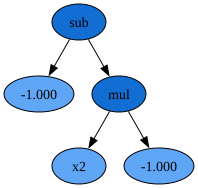

In [54]:
import graphviz
import os

os.environ["PATH"] += os.pathsep + r'C:\Program Files\Graphviz\bin'


dot_data = est_gp._program.export_graphviz()
graph = graphviz.Source(dot_data)
graph.render('images/ex1_child', format='png', cleanup=True)
graph

In [61]:
similarity_vector = est_gp._program.similarity_vec

feature_map = results[0][MetricKey.feature_map]
labels = [None] * len(feature_map)
for key, idx in feature_map.items():
    labels[idx] = str(key)

for i, vec in enumerate(similarity_vector):
    print(f"{labels[i]}: {vec}" )

add: 0.0
sub: 1.0
mul: 0.5
div: 0.0
x1: 0.0
x2: 0.25
CONST_Q0_To_Q1: 0.0
CONST_Q1_To_Q2: 0.75
CONST_Q2_To_Q3: 0.0
CONST_Q3_To_Q4: 0.0
